# Instance Space Analysis: A toolkit for the assessment of algorithmic power

Instance Space Analysis (ISA) is a methodology for assessing the strengths and weaknesses of an
algorithm, and an approach to objectively compare algorithmic power without bias introduced by a
restricted choice of test instances. At its core is modelling the relationship between an
instance's structural properties and the performance of a group of algorithms. ISA allows the
construction of **footprints** for each algorithm, defined as regions in the instance space where
we statistically infer good performance. Other insights ISA provides include:

- Objective metrics of each algorithm's footprint across the instance space as a measure of
  algorithmic power;
- Explanation through visualisation of how instance features correlate with algorithm performance
  in various regions of the instance space;
- Visualisation of the distribution and diversity of existing benchmark and real-world instances;
- Assessment of the adequacy of the features used to characterise an instance;
- Partitioning of the instance space into recommended regions for automated algorithm selection;
- Distinguishing areas of the instance space where it may be useful to generate additional
  instances to gain further insights.

This notebook is the Python counterpart of the MATLAB toolkit's `liveDemoIS.m`: it walks through
the same stages, in the same order, using this repository's Python API instead. Only the key
options are demonstrated here — see the repository `README.md` for the complete option reference,
`integration_demo.py` for a complete runnable example, and `example_plugin.py` for how to add a
custom stage to the pipeline.

If you follow the ISA methodology, please cite:

> K. Smith-Miles and M.A. Muñoz. *Instance Space Analysis for Algorithm Testing: Methodology and
> Software Tools*. ACM Comput. Surv. 55(12:255), 1-31, DOI:10.1145/3572895, 2023.

If you specifically use this code, please also cite the two references in the README's
*Citation* section (the Zenodo/GitHub software record and the SoftwareX paper).


## Licence and disclaimer

This toolkit is distributed under the PolyForm Noncommercial 1.0.0 licence, matching the MATLAB
`InstanceSpace` toolkit: free for noncommercial research and educational use; commercial use
requires prior written permission.

**DISCLAIMER: This repository contains research code. On occasion, new features will be added or
changes made that may result in crashes. Although we have made every effort to minimise bugs, this
code comes with NO GUARANTEES. If you encounter any issues, please let us know as soon as possible
through this repository's [issue tracker](https://github.com/andremun/pyInstanceSpace/issues).**


## Installation instructions

Requires Python 3.12. Install the published package with:

```bash
pip install instancespace
```

or, for local development, `poetry install` from the repository root (see the *Development
Environment Setup Guide* in `README.md`). Every dependency this toolkit needs — scikit-learn and
scikit-optimize for PYTHIA's classifiers and hyperparameter search, shapely and alphashape for
TRACE's footprints, pygad for SIFTED's feature-combination search — installs automatically; no
separate toolboxes are required.


## Setting up the environment and loading the training data

An `InstanceSpace` is constructed from a `Metadata` object (loaded from a `metadata.csv`, see
`README.md` for the column-naming convention), an `InstanceSpaceOptions` object, and — as
`integration_demo.py` shows — an explicit, ordered list of the `Stage` classes to run; unset
option fields fall back to the documented defaults. This notebook uses the same reference dataset
as the test suite's MATLAB-validation harness (`tests/matlab_reference/`): 212 training instances,
10 features, and 10 classification algorithms scored by misclassification error. We set
`perf.max_perf = False` and `perf.abs_perf = True` because a lower error is better and "good"
performance is judged absolutely, and `perf.epsilon = 0.20` so an algorithm is "good" on an
instance if its misclassification error is below 20% (these three also happen to be the toolkit's
defaults, but are set explicitly here to make the choice visible).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import MultiPoint, MultiPolygon, Point

from instancespace.data.metadata import from_csv_file
from instancespace.data.options import InstanceSpaceOptions, PerformanceOptions
from instancespace.instance_space import ExploreStage, InstanceSpace
from instancespace.stages.cloister import CloisterStage
from instancespace.stages.pilot import PilotStage
from instancespace.stages.prelim import PrelimStage
from instancespace.stages.preprocessing import PreprocessingStage
from instancespace.stages.pythia import PythiaStage
from instancespace.stages.sifted import SiftedStage
from instancespace.stages.trace import TraceStage

INPUT_DIR = Path("tests/matlab_reference/input")

train_metadata = from_csv_file(INPUT_DIR / "metadata.csv")

perf = PerformanceOptions.default(max_perf=False, abs_perf=True, epsilon=0.20)
options = InstanceSpaceOptions.default(
    parallel=None, perf=perf, auto=None, bound=None, norm=None, selvars=None,
    sifted=None, pilot=None, cloister=None, pythia=None, trace=None, outputs=None,
)

space = InstanceSpace(
    train_metadata,
    options,
    stages=[
        PreprocessingStage,
        PrelimStage,
        SiftedStage,
        PilotStage,
        PythiaStage,
        CloisterStage,
        TraceStage,
    ],
)

print(f"{len(train_metadata.instance_labels)} training instances, "
      f"{len(train_metadata.feature_names)} features, "
      f"{len(train_metadata.algorithm_names)} algorithms")


212 training instances, 10 features, 10 algorithms


### Running the pipeline, one stage at a time

Rather than one opaque `build()` call, `run_iter()` runs the pipeline the same way `build()` does
but pauses after every stage, handing back exactly the `Stage` class that just ran and its own
output — the Python equivalent of MATLAB's `obj.build('stages', {...})` calls, made once per
stage. Each of the following sections calls `next()` on it once, to run precisely one stage, and
inspects that stage's own result before moving to the next section. CLOISTER and PYTHIA both only
depend on PILOT's output (not on each other), so the scheduler runs them back to back in either
order; the assertions below simply record which order this run took.

The first stage, `PreprocessingStage`, has no MATLAB-side counterpart of its own — MATLAB folds
instance/feature/algorithm selection and missing-value removal into its own data-loading step. We
run and inspect it here, before PRELIM.


In [2]:
stage_iter = space.run_iter()

stage, preprocessing_out = next(stage_iter)
assert stage is PreprocessingStage
print(f"{len(preprocessing_out.inst_labels)} instances, "
      f"{len(preprocessing_out.feat_labels)} features, "
      f"{len(preprocessing_out.algo_labels)} algorithms selected for processing")


2026-07-28 21:23:53.780 | INFO     | instancespace.stages.preprocessing:select_features_and_algorithms:229 - [PREPROCESSING] -----------------------------------------------------------------


2026-07-28 21:23:53.781 | INFO     | instancespace.stages.preprocessing:select_features_and_algorithms:257 - [PREPROCESSING] -----------------------------------------------------------------


[DEBUG]: running PreprocessingStage
212 instances, 10 features, 10 algorithms selected for processing


## PRELIM: loading and preparing the data

PRELIM removes instances/features with excessive missing values, optionally bounds outliers
(median ± five times the interquartile range), and normalises every feature and performance column
with a Box-Cox transform followed by a Z-score. It then identifies, per instance, which algorithms
count as "good" under the `perf` options set above.


In [3]:
stage, prelim_out = next(stage_iter)
assert stage is PrelimStage

n_inst, n_feat = prelim_out.x.shape
n_algo = prelim_out.y.shape[1]
print(f"{n_inst} instances, {n_feat} features, {n_algo} algorithms")
print(f"{np.mean(prelim_out.beta) * 100:.1f}% of instances are 'easy' "
      f"(at least the required fraction of algorithms performs well on them)")


2026-07-28 21:23:53.788 | INFO     | instancespace.stages.prelim:_log:215 - [PRELIM] -------------------------------------------------------------------------


2026-07-28 21:23:53.790 | INFO     | instancespace.stages.prelim:_log:215 - [PRELIM] -> Calculating the binary measure of performance


2026-07-28 21:23:53.790 | INFO     | instancespace.stages.prelim:_log:215 - [PRELIM] -> Minimizing performance.


2026-07-28 21:23:53.791 | INFO     | instancespace.stages.prelim:_log:215 - [PRELIM] An algorithm is good if its performance is less than 0.2


2026-07-28 21:23:53.792 | INFO     | instancespace.stages.prelim:_log:215 - [PRELIM] -> For 11% of the instances there is more than one best algorithm.


...

2026-07-28 21:23:53.930 | INFO     | instancespace.stages.prelim:_log:215 - [PRELIM] -------------------------------------------------------------------


2026-07-28 21:23:53.931 | DEBUG    | instancespace.stages.prelim:_log_detail:220 - [PRELIM] path: .


2026-07-28 21:23:53.931 | DEBUG    | instancespace.stages.prelim:_log_detail:220 - [PRELIM] path.is_file(file_idx): False


2026-07-28 21:23:53.932 | INFO     | instancespace.stages.prelim:_log:215 - [PRELIM] -> Using the complete set of the instances.


[DEBUG]: running PrelimStage
212 instances, 10 features, 10 algorithms
68.9% of instances are 'easy' (at least the required fraction of algorithms performs well on them)


## SIFTED: automated feature selection

SIFTED keeps the features most correlated with algorithm performance, then — if more than a
handful survive — clusters the remainder by cross-correlation and picks one representative feature
per cluster (searching combinations directly if there are few enough, or with a genetic algorithm
otherwise). Set `opts.sifted.flag = False` to skip this and keep every feature.


In [4]:
stage, sifted_out = next(stage_iter)
assert stage is SiftedStage

print(f"Features before SIFTED ({len(train_metadata.feature_names)}):")
print(" ", train_metadata.feature_names)
print(f"Features after SIFTED ({len(sifted_out.feat_labels)}):")
print(" ", sifted_out.feat_labels)


2026-07-28 21:23:53.938 | INFO     | instancespace.stages.sifted:_log:357 - [SIFTED] -> Selecting features based on correlation with performance.


2026-07-28 21:23:54.031 | INFO     | instancespace.stages.sifted:_log:357 - [SIFTED] -> Selecting features based on correlation clustering.


[DEBUG]: running SiftedStage


2026-07-28 21:23:54.064 | DEBUG    | instancespace.stages.sifted:_log_detail:362 - [SIFTED]     Suggested k value 2 with silhoulette score of 0.2995


/home/user/pyInstanceSpace/.venv/lib/python3.13/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")
/home/user/pyInstanceSpace/.venv/lib/python3.13/site-packages/pygad/pygad.py:1162: UserWarning: Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number of genes, or number of solutions in population is large.
  warnings.warn("Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number of genes, or number of 

2026-07-28 21:26:01.416 | INFO     | instancespace.stages.sifted:_log:357 - [SIFTED] Cost value of the GA algorithm is:  0.3541528239202658


2026-07-28 21:26:01.418 | INFO     | instancespace.stages.sifted:_log:357 - [SIFTED] -> Keeping 6 out of 10 features (clustering).


2026-07-28 21:26:01.418 | DEBUG    | instancespace.stages.sifted:_log_detail:362 - [SIFTED] Bydensity value is : False


Features before SIFTED (10):
  ['Max_Normalized_Entropy_attributes', 'Normalized_Entropy_Class_Attribute', 'Mean_Mutual_Information_Attribute_Class', 'ErrorRate_Decision_Node', 'WeightedDist_StdDev', 'Max_Feature_Efficiency_F3', 'Collective_Feature_Efficiency_F4', 'Training_Error_Linear_Classifier_L2', 'Fraction_Points_Class_Boundary_N1', 'Nonlinearity_Nearest_Neighbor_Classifier_N4']
Features after SIFTED (6):
  ['Max_Normalized_Entropy_attributes', 'Mean_Mutual_Information_Attribute_Class', 'WeightedDist_StdDev', 'Max_Feature_Efficiency_F3', 'Training_Error_Linear_Classifier_L2', 'Nonlinearity_Nearest_Neighbor_Classifier_N4']


## PILOT: obtaining a two-dimensional projection

PILOT finds the linear projection `Z = X @ A.T` of the (SIFTED-selected) features that best
reconstructs both the features and algorithm performance jointly, solved numerically with BFGS by
default (`opts.pilot.analytic = True` switches to the analytic solution, though we recommend
leaving this off — it can be unstable on poorly conditioned data).


2026-07-28 21:26:01.428 | INFO     | instancespace.stages.pilot:_pilot_print:179 - [PILOT]   -> PILOT is using random starting points for BFGS.


2026-07-28 21:26:01.429 | INFO     | instancespace.stages.pilot:_pilot_print:179 - [PILOT] -------------------------------------------------------------------------


2026-07-28 21:26:01.430 | INFO     | instancespace.stages.pilot:_pilot_print:179 - [PILOT]   -> PILOT is solving numerically the projection problem.


2026-07-28 21:26:01.430 | INFO     | instancespace.stages.pilot:_pilot_print:179 - [PILOT]   -> This may take a while. Trials will not be run sequentially.


2026-07-28 21:26:01.431 | INFO     | instancespace.stages.pilot:_pilot_print:179 - [PILOT] -------------------------------------------------------------------------


...

2026-07-28 21:26:02.607 | DEBUG    | instancespace.stages.pilot:_pilot_print_detail:188 - [PILOT] Pilot has completed trial 5


2026-07-28 21:26:02.613 | INFO     | instancespace.stages.pilot:_pilot_print:179 - [PILOT] -------------------------------------------------------------------------


2026-07-28 21:26:02.614 | INFO     | instancespace.stages.pilot:_pilot_print:179 - [PILOT]   -> PILOT has completed. The projection matrix A is:


2026-07-28 21:26:02.615 | INFO     | instancespace.stages.pilot:_pilot_print:179 - [PILOT] [[ 0.2195   0.3127  -0.3413   0.2668  -0.04034 -0.3083 ]
 [ 0.2517   0.03836 -0.4438  -0.05133  0.4368  -0.06384]]


Projection matrix A shape: (2, 6)


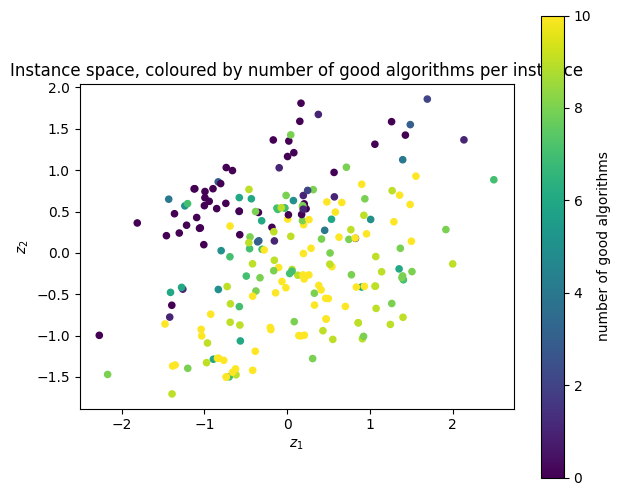

In [5]:
stage, pilot_out = next(stage_iter)
assert stage is PilotStage

z = np.asarray(pilot_out.z)
print(f"Projection matrix A shape: {np.asarray(pilot_out.a).shape}")

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(z[:, 0], z[:, 1], c=prelim_out.num_good_algos, cmap="viridis", s=20)
fig.colorbar(scatter, ax=ax, label="number of good algorithms")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Instance space, coloured by number of good algorithms per instance")
ax.set_aspect("equal")
plt.show()


CLOISTER and PYTHIA are independent of each other — both depend only on PILOT's output — so the
scheduler may run either one first. We pull both results here, then show them in the same order
as MATLAB's demo regardless of which one actually ran first.


In [6]:
_wave = {}
for _ in range(2):
    stage, output = next(stage_iter)
    _wave[stage.__name__] = output
cloister_out = _wave["CloisterStage"]
pythia_out = _wave["PythiaStage"]


2026-07-28 21:26:02.806 | INFO     | instancespace.stages.pythia:pythia:334 - [PYTHIA] =========================================================================


2026-07-28 21:26:02.807 | INFO     | instancespace.stages.pythia:pythia:338 - [PYTHIA] -> Summoning PYTHIA to train the prediction models.


2026-07-28 21:26:02.808 | INFO     | instancespace.stages.pythia:pythia:339 - [PYTHIA] =========================================================================


2026-07-28 21:26:02.809 | INFO     | instancespace.stages.pythia:pythia:343 - [PYTHIA]   -> Initializing PYTHIA.


2026-07-28 21:26:02.810 | INFO     | instancespace.stages.pythia:pythia:370 - [PYTHIA]  -> PYTHIA is training a 'svm' classifier.


...

2026-07-28 21:33:28.279 | INFO     | instancespace.stages.pythia:_generate_summary:1000 - [PYTHIA]   -> PYTHIA has completed! Performance of the models:
   Algorithms  Avg_Perf_all_instances  Std_Perf_all_instances  \
0          NB                   0.173                   0.129   
1         LDA                   0.214                   0.211   
2         QDA                   0.381                   0.279   
3        CART                   0.136                   0.117   
4         J48                   0.127                   0.117   
5         KNN                   0.134                   0.118   
6       L_SVM                   0.136                   0.128   
7    poly_SVM                   0.197                   0.145   
8     RBF_SVM                   0.135                   0.127   
9       RandF                   0.160                   0.201   
10     Oracle                   0.095                   0.097   
11   Selector                   0.137                   0.119   

 

2026-07-28 21:33:28.280 | INFO     | instancespace.stages.cloister:cloister:183 - [CLOISTER]   -> CLOISTER is using correlation to estimate a boundary for the space.


2026-07-28 21:33:28.310 | INFO     | instancespace.stages.cloister:cloister:201 - [CLOISTER] -----------------------------------------------------------------


2026-07-28 21:33:28.311 | INFO     | instancespace.stages.cloister:cloister:202 - [CLOISTER]   -> CLOISTER has completed.


[DEBUG]: running CloisterStage


## CLOISTER: finding the empirical bounds of the space

CLOISTER uses the correlation between features to estimate the boundary of the region of feature
space that is actually reachable — useful for judging whether new or synthetic instances fall
within the range the model was trained on.


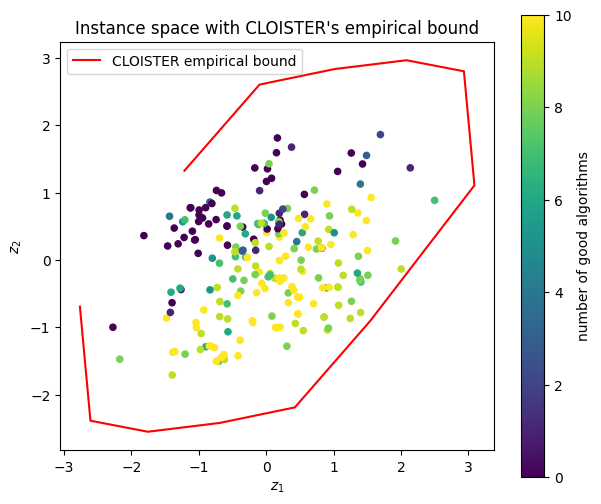

In [7]:
z_edge = np.asarray(cloister_out.z_edge)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(z[:, 0], z[:, 1], c=prelim_out.num_good_algos, cmap="viridis", s=20)
ax.plot(z_edge[:, 0], z_edge[:, 1], color="red", lw=1.5, label="CLOISTER empirical bound")
fig.colorbar(scatter, ax=ax, label="number of good algorithms")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Instance space with CLOISTER's empirical bound")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()


## PYTHIA: building an oracle for algorithm selection

PYTHIA trains one binary (good / not-good) classifier per algorithm over the two-dimensional
instance space — a scikit-learn `SVC`, tuned by stratified cross-validation via a Sobol-sampled
grid search or Bayesian optimisation (`opts.pythia.use_grid_search`). Its summary table reports
each algorithm's cross-validated accuracy.


,CV_model_accuracy
Algorithms,
NB,83.704
LDA,75.168
QDA,66.667
CART,86.667
J48,88.82
KNN,85.207
L_SVM,89.809
poly_SVM,83.636
RBF_SVM,87.73


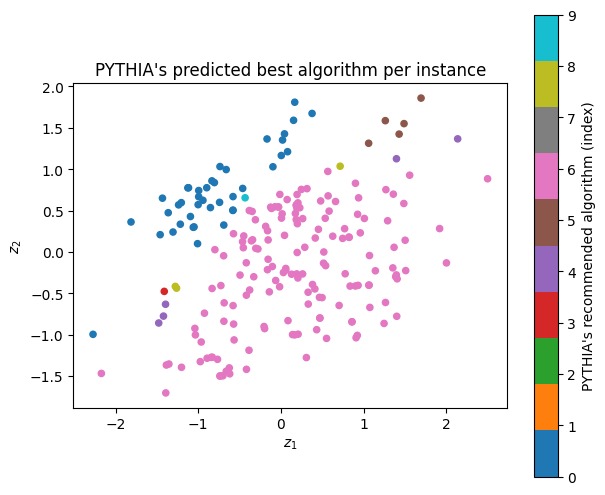

In [8]:
display(pythia_out.pythia_summary.set_index("Algorithms")[["CV_model_accuracy"]])

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(z[:, 0], z[:, 1], c=pythia_out.selection0, cmap="tab10", s=20)
fig.colorbar(scatter, ax=ax, label="PYTHIA's recommended algorithm (index)")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("PYTHIA's predicted best algorithm per instance")
ax.set_aspect("equal")
plt.show()


## TRACE: calculating the algorithm footprints

TRACE builds each algorithm's footprint — the region of the instance space, defined with `shapely`
polygons, where PYTHIA predicts good performance — then prunes sections whose evidence (measured
by a minimum purity value) is too weak.


In [9]:
stage, trace_out = next(stage_iter)
assert stage is TraceStage

display(trace_out.trace_summary.set_index("Algorithm")[
    ["Area_Good", "Density_Good", "Purity_Good"]
])


2026-07-28 21:33:28.609 | INFO     | instancespace.stages.trace:_run:308 - [TRACE] ========================================================================


2026-07-28 21:33:28.609 | INFO     | instancespace.stages.trace:_run:312 - [TRACE] -> Calling TRACE to perform the footprint analysis.


2026-07-28 21:33:28.610 | INFO     | instancespace.stages.trace:_run:313 - [TRACE] ========================================================================


2026-07-28 21:33:28.610 | INFO     | instancespace.stages.trace:_run:319 - [TRACE]   -> TRACE will use PYTHIA's results to calculate the footprints.


2026-07-28 21:33:28.611 | INFO     | instancespace.stages.trace:_log:260 - [TRACE]   -> TRACE is calculating the space area and density.


...

2026-07-28 21:33:33.486 | INFO     | instancespace.stages.trace:_log:260 - [TRACE] ------------------------------------------------------------------------


2026-07-28 21:33:33.487 | INFO     | instancespace.stages.trace:_log:260 - [TRACE]   -> TRACE is preparing the summary table.


2026-07-28 21:33:33.489 | INFO     | instancespace.stages.trace:_log:260 - [TRACE]   -> TRACE has completed. Footprint analysis results:


2026-07-28 21:33:33.493 | INFO     | instancespace.stages.trace:_log:260 - [TRACE] 
  Algorithm  Area_Good  Area_Good_Normalised  Density_Good  \
0        NB   4.953881              0.603405     23.617846   
1       LDA   5.267157              0.641563     25.250816   
2       QDA   1.558156              0.189790     30.163858   
3      CART   5.737132              0.698808     25.622556   
4       J48   5.386088              0.656049     26.364218   
5       KNN   5.968811              0.727028     25.298169   
6     L_SVM   5.078470              0.618580     27.961177   
7  poly_SVM   3.635626              0.442835     25.855248   
8   RBF_SVM   5.700867              0.694391     25.434727   
9     RandF   5.594594              0.681446     26.811596   

   Density_Good_Normalised  Purity_Good  Area_Best  Area_Best_Normalised  \
0                 0.994358          1.0   0.804818               0.09803   
1                 1.063109          1.0   0.000000               0.00000   
2    

,Area_Good,Density_Good,Purity_Good
Algorithm,,,
NB,4.953881,23.617846,1.0
LDA,5.267157,25.250816,1.0
QDA,1.558156,30.163858,1.0
CART,5.737132,25.622556,1.0
J48,5.386088,26.364218,1.0
KNN,5.968811,25.298169,1.0
L_SVM,5.078470,27.961177,1.0
poly_SVM,3.635626,25.855248,1.0
RBF_SVM,5.700867,25.434727,1.0


### Finishing the run

Every stage's raw output above is a `NamedTuple`; merging them, in the order they ran, reproduces
exactly the combined result `build()` assembles internally (a later stage's output overwrites an
earlier stage's field of the same name — e.g. SIFTED's `x` replacing PREPROCESSING's — the same
way it would inside `build()`). Handing that to `space` lets `space.model` be built from it, the
same way `build()` does at the end, without re-running the pipeline a second time.


In [10]:
final_output = {}
for stage_output in (
    preprocessing_out, prelim_out, sifted_out, pilot_out, cloister_out, pythia_out, trace_out,
):
    final_output.update(stage_output._asdict())
space._final_output = final_output  # noqa: SLF001

model = space.model
print("model assembled from the stage-by-stage run above.")


model assembled from the stage-by-stage run above.


## Post-processing: preparing results for further analysis or publication

`Model.save_to_csv()` and `Model.save_graphs()` write the tables and plots shown above (and more)
to disk, matching MATLAB's `obj.save()` / `scriptcsv` / `scriptpng`. There is no Python equivalent
yet of MATLAB's `model.mat` / `InstanceSpace.load()` round-trip (tracked as a roadmap item) — a
Python session must `build()` from scratch rather than reloading a previously saved model.


In [11]:
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
model.save_to_csv(output_dir)
model.save_graphs(output_dir)
print(f"wrote CSVs and graphs to {output_dir.resolve()}")


/home/user/pyInstanceSpace/instancespace/_serialisers.py:182: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_summary.rename(columns={"Algorithm": "Row"}, inplace=True)


-> Writing the data on CSV files for posterior analysis.
-> Producing the plots.


/home/user/pyInstanceSpace/instancespace/_serialisers.py:556: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


wrote CSVs and graphs to /home/user/pyInstanceSpace/output


/home/user/pyInstanceSpace/instancespace/_serialisers.py:606: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


<Figure size 640x480 with 0 Axes>

## Exploring the Instance Space model

`explore()` projects new instances into the already-fitted space and evaluates PYTHIA and TRACE
against them, without re-fitting anything: it re-applies the stored PRELIM bounds/scaling, the
SIFTED feature selection, the PILOT projection matrix, and the trained PYTHIA classifiers and
TRACE footprints. Where MATLAB's `exploreIS.m` reads a `metadata_test.csv` from a directory,
Python's `explore()` takes an already-loaded `Metadata` object directly.


## Setting up the test data, and testing PYTHIA and the footprints together

The test set uses the same metadata format as training: an `Instances` identifier column and
`feature_` columns (`algo_` performance columns are optional and unused at inference). This
notebook's test set re-uses all 212 training instances and adds 23 new ones.


In [12]:
test_metadata = from_csv_file(INPUT_DIR / "metadata_test.csv")
print(f"{len(test_metadata.instance_labels)} test instances, "
      f"{len(test_metadata.feature_names)} features")


235 test instances, 10 features


### The one call: `explore()`

Calling `explore()` once runs every inference stage and returns an `ExploreResult` with the
projected coordinates, the per-algorithm predictions, and the footprint membership.

The log line below is `explore()` reporting that it detected a Python-built model and converted it
internally to the flattened form it consumes; the fitted scikit-learn model stays available on
`space.model`.


In [13]:
result = space.explore(test_metadata)
print(f"z {result.z.shape}, y_hat {result.y_hat.shape}, "
      f"in_good {result.in_good.shape}, in_best {result.in_best.shape}")


2026-07-28 21:33:38.489 | WARNING  | instancespace.instance_space:_explore_prelim:696 - explore(): 9.8% of test instances have at least one feature outside the training bounds and were clipped to them. This suggests the test set may not be well represented by the trained instance space; consider retraining with a combined dataset.


z (235, 2), y_hat (235, 10), in_good (235, 10), in_best (235, 10)


### Inspecting it one stage at a time

`explore_stage_iter()` is `explore()`'s own stage-by-stage generator, the inference-time counterpart of
the `run_iter()` walk-through above: it yields each stage's output as it is produced (`prelim`,
`sifted`, `pilot`, `pythia`, `trace`), so you can look at each stage before the next one runs. A
few numbers per stage summarise how the test set moved through the pipeline. For each stage run
and inspected on its own in more depth, see `docs/explore_validation.ipynb`.


In [14]:
z_train = z
training_region = MultiPoint([tuple(p) for p in z_train]).convex_hull
n = len(test_metadata.instance_labels)

stages = {}
n_feat_in = None
for stage_name, output in space.explore_stage_iter(test_metadata):
    stages[stage_name] = output
    if stage_name == ExploreStage.PRELIM:
        n_feat_in = output.shape[1]
        beyond = np.mean(np.abs(output) > 3) * 100
        print(f"prelim : {beyond:.1f}% of scaled feature values fall beyond \u00b13 "
              f"standard deviations from the training mean")
    elif stage_name == ExploreStage.SIFTED:
        print(f"sifted : kept {output.shape[1]} of {n_feat_in} features")
    elif stage_name == ExploreStage.PILOT:
        inside = sum(training_region.covers(Point(x, y)) for x, y in output)
        print(f"pilot  : {inside} of {n} test instances project inside the training region, "
              f"{n - inside} outside it")
    elif stage_name == ExploreStage.PYTHIA:
        _, _, selection0 = output
        print(f"pythia : {int((selection0 < 0).sum())} of {n} instances have no algorithm "
              f"predicted good")
    elif stage_name == ExploreStage.TRACE:
        in_good, _ = output
        outside = int((in_good.sum(axis=1) == 0).sum())
        print(f"trace  : {outside} of {n} instances fall outside every good footprint")


2026-07-28 21:33:38.554 | WARNING  | instancespace.instance_space:_explore_prelim:696 - explore(): 9.8% of test instances have at least one feature outside the training bounds and were clipped to them. This suggests the test set may not be well represented by the trained instance space; consider retraining with a combined dataset.


prelim : 0.0% of scaled feature values fall beyond ±3 standard deviations from the training mean
sifted : kept 6 of 10 features
pilot  : 232 of 235 test instances project inside the training region, 3 outside it
pythia : 43 of 235 instances have no algorithm predicted good
trace  : 62 of 235 instances fall outside every good footprint


### Projecting the data

Below, the test instances are drawn over the training instances (grey) that define the space;
test instances that fall outside the training region (the convex hull of the training projection,
dashed) are drawn in red.


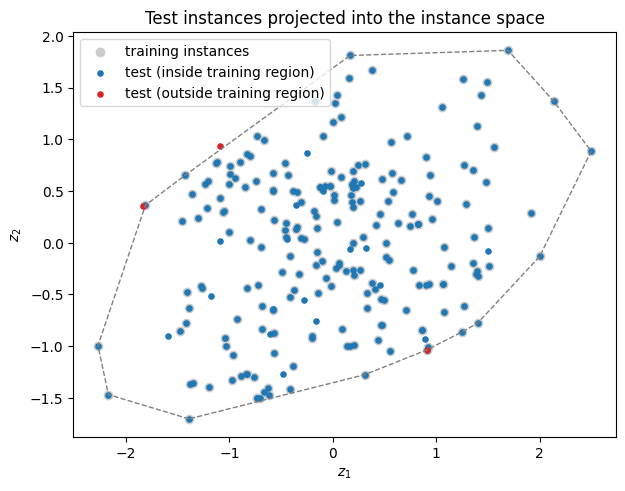

In [15]:
z_test = stages[ExploreStage.PILOT]
inside = np.array([training_region.covers(Point(x, y)) for x, y in z_test])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
ax.scatter(z_test[inside, 0], z_test[inside, 1], c="tab:blue", s=14,
           label="test (inside training region)")
ax.scatter(z_test[~inside, 0], z_test[~inside, 1], c="tab:red", s=14,
           label="test (outside training region)")
hx, hy = training_region.exterior.xy
ax.plot(hx, hy, color="0.5", lw=1.0, ls="--")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Test instances projected into the instance space")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()


### Testing PYTHIA

For each algorithm, PYTHIA predicts whether it will perform well on an instance. Below, the test
instances are coloured by PYTHIA's good/bad prediction for one algorithm.


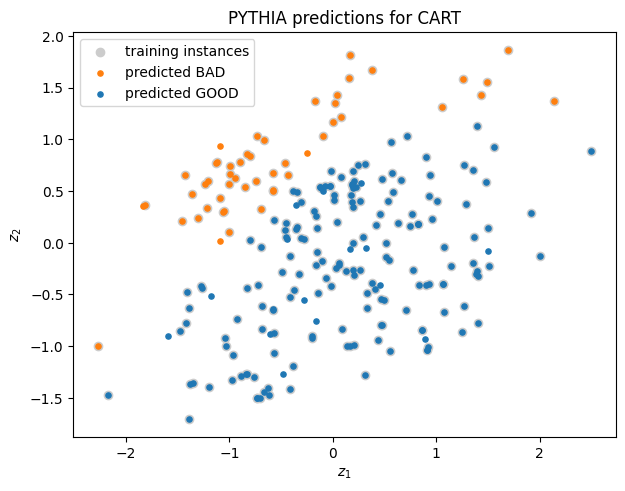

In [16]:
y_hat, pr0_hat, selection0 = stages[ExploreStage.PYTHIA]
algo_labels = train_metadata.algorithm_names

algo = "CART" if "CART" in algo_labels else algo_labels[0]
j = algo_labels.index(algo)
good = y_hat[:, j]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
ax.scatter(z_test[~good, 0], z_test[~good, 1], c="tab:orange", s=14, label="predicted BAD")
ax.scatter(z_test[good, 0], z_test[good, 1], c="tab:blue", s=14, label="predicted GOOD")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title(f"PYTHIA predictions for {algo}")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()


### Testing the footprints

TRACE records, for each algorithm, the region of the instance space where good performance was
statistically inferred at training time. At inference, each instance is checked for membership in
that region. Below, one algorithm's good footprint is drawn together with the test instances that
fall inside it.


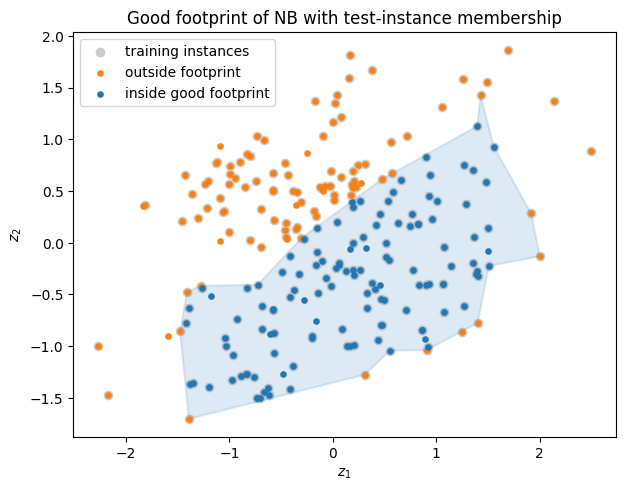

In [17]:
in_good, in_best = stages[ExploreStage.TRACE]

# pick an algorithm that has a non-empty good footprint
j = next(i for i, fp in enumerate(model.trace.good) if fp.polygon is not None)
algo = algo_labels[j]
footprint = model.trace.good[j].polygon
inside = in_good[:, j]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
regions = footprint.geoms if isinstance(footprint, MultiPolygon) else [footprint]
for region in regions:
    xs, ys = region.exterior.xy
    ax.fill(xs, ys, facecolor="tab:blue", alpha=0.15, edgecolor="tab:blue", linewidth=1.5)
ax.scatter(z_test[~inside, 0], z_test[~inside, 1], c="tab:orange", s=14, label="outside footprint")
ax.scatter(z_test[inside, 0], z_test[inside, 1], c="tab:blue", s=14, label="inside good footprint")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title(f"Good footprint of {algo} with test-instance membership")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()


## Additional resources

- `README.md` for the complete option reference and repository layout.
- `integration_demo.py` for a complete, minimal, runnable example.
- `example_plugin.py` for writing a custom `Stage` and slotting it into the pipeline.
- `tests/matlab_reference/` and `docs/explore_validation.ipynb` for how this port is validated
  stage by stage against the MATLAB implementation.
- The Melbourne Algorithm Test Instance Library with Data Analytics
  ([MATILDA](http://matilda.unimelb.edu.au/matilda/)), which this toolkit is expected to power for
  online analysis.


## Using this on your own data

To run this on your own problem, replace the two metadata paths in the setup cells with your own
files (same format as the repository README) and re-run. The whole workflow is just:

```python
space = InstanceSpace(train_metadata, options, stages=[...])
space.build()
result = space.explore(test_metadata)
```

Everything above is that call, opened up stage by stage.


## Acknowledgements

This toolkit and the ISA methodology are the product of collaborative research led by the
MATILDA team at the University of Melbourne and collaborators. See the repository README's
*Acknowledgements* section for the full list of funding and contributors.
